In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [2]:
CURRENT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(CURRENT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
RAW_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "raw_data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")

In [3]:
iea = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, 'IEA_policies_clean.csv'))
iea.head()

,year,jurisdiction,title,description,status,iso_alpha_3,country,topic,type,category
0,2011,National,Law 47-09 on Energy Efficiency,"Law 47-09, or the ""Law on Energy Efficiency"" a...",In force,MAR,Morocco,NaN,NaN,NaN
1,2017,National,Swiss Energy Strategy 2050,Swiss Energy Strategy 2050The Swiss Energy Str...,In force,CHE,Switzerland,Economy-wide,"Master Energy Plan,Framework legislation",NaN
2,2009,National,Buy Smart project,"The aim of the Buy Smart""- project is to promo...",Ended,DEU,Germany,NaN,NaN,NaN
3,2010,National,A Group of Energy Efficiency Measures in Agric...,This group consists of five PAMs.1. Biomass bo...,In force,FIN,Finland,NaN,NaN,NaN
4,1999,National,New Buses,Financial assistance to regions and municipali...,In force,ITA,Italy,NaN,NaN,NaN


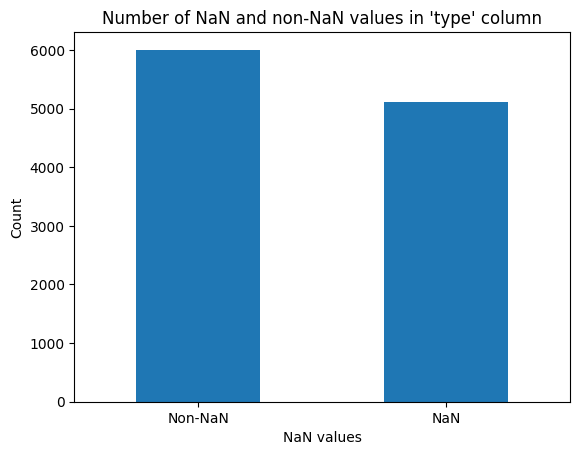

In [4]:
# Plot how many na and non-nan values in col type
iea['type'].isna().value_counts().plot(kind='bar')
plt.title("Number of NaN and non-NaN values in 'type' column")
plt.xlabel("NaN values")
plt.ylabel("Count")
plt.xticks([0, 1], ['Non-NaN', 'NaN'], rotation=0)
plt.show()

In [5]:
# CPSI Scoring & Index Calculation

#IEA Raw Policies CSV
iea["status"] = iea["status"].str.lower()
iea["full_text"] = (iea["title"].fillna("") + " " + iea["description"].fillna("")).str.lower()

# Filter for relevant years
# iea = iea[(iea["year"] >= 2000) & (iea["year"] <= 2022)].copy()

# Get max year
max_year = iea["year"].max()
print(f"Max year in IEA data: {max_year}")

# Expand 'in force' policies for every year until 2022 (If it finds a policy in force, it will add it for every year until 2022)
expanded_rows = []
for _, row in iea.iterrows():
    if row["status"] == "in force":
        for year in range(int(row["year"]), max_year + 1):
            new_row = row.copy()
            new_row["year"] = year
            expanded_rows.append(new_row)
    elif row["status"] == "ended": # if the policy is ended, it will only be added for the year it was created
        expanded_rows.append(row)

iea = pd.DataFrame(expanded_rows)
iea = iea.sort_values(by="year").reset_index(drop=True)

### ! Alternate IEA dataframe without expanding policies for subsequent years + without ended

#iea = pd.read_csv("/Users/cynthiasalinas/Documents/econ_climate/important/IEA_policies_raw.csv", encoding="ISO-8859-1")
#iea = iea[iea["status"].str.lower() == "in force"]
#iea = iea[(iea["year"] >= 2000) & (iea["year"] <= 2022)].copy()
#iea["full_text"] = (iea["title"].fillna("") + " " + iea["description"].fillna("")).str.lower()

#Type & Category Mappings
type_mapping = pd.read_csv("Type_C-Level_Mapping.csv")
category_mapping = pd.read_csv("Category_Theme_Mapping.csv")
topic_mapping = pd.read_csv("Topic_Theme_Mapping.csv")

# Dictionaries for mappings
type_dict = dict(zip(type_mapping['type'], type_mapping['C_level']))
topic_dict = dict(zip(topic_mapping['topic'], topic_mapping['topic_theme_14_refined']))
category_dict = dict(zip(category_mapping['category'], category_mapping['category_theme_27']))

count_policies = len(iea)
print(f"Number of policies: {count_policies}")

Max year in IEA data: 2028
Number of policies: 151748


In [6]:
iea.head()

,year,jurisdiction,title,description,status,iso_alpha_3,country,topic,type,category,full_text
0,1948,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...
1,1949,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...
2,1950,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...
3,1951,National,Electricity tax,"Introduced in 1951, an electricity tax has bee...",in force,NOR,Norway,NaN,NaN,NaN,"electricity tax introduced in 1951, an electri..."
4,1951,National,Oilfields (Regulation and Development) Act 1948,"This states that Central Government may, by pr...",in force,IND,India,NaN,NaN,NaN,oilfields (regulation and development) act 194...


In [7]:
# Define NLP keywords for C1-C4 categories

keywords = {
    'C1': ['ban', 'banned', 'banning', 'prohibit', 'prohibition', 'restriction', 'restricted', 'mandate', 'mandatory', 'outlawed', 'phase-out', 'elimination', 'forbidden', 'sales ban', 'exploration ban'],
    'C2': ['tax', 'levy', 'pricing', 'carbon pricing', 'fuel tax', 'tariff', 'subsidy removal'],
    'C3': ['standard', 'performance', 'emissions limit', 'efficiency code', 'compliance', 'emissions cap', 'minimum standard', 'permitting'],
    'C4': ['grant', 'funding', 'finance', 'subsidy', 'support', 'r&d', 'research', 'development', 'information', 'education', 'training', 'capacity-building', 'knowledge', 'awareness', 'incentives', 'investment', 'pilot program', 'dialogue', 'workshops', 'partnership']
}

# NLP-based scoring function
def nlp_score(row):
    text = ' '.join([str(row['topic']), str(row['description'])]).lower()
    for level, words in keywords.items():
        if any(word in text for word in words):
            return {'C1': 1.0, 'C2': 0.75, 'C3': 0.5, 'C4': 0.25}[level]
    return 0.25

# Assign C-level scores based on type
def type_score(row):
    if pd.notna(row['type']):
        mapping = type_mapping[type_mapping['type'] == row['type']]
        if not mapping.empty:
            level = mapping.iloc[0]['C_level']
            return {'C1': 1.0, 'C2': 0.75, 'C3': 0.5, 'C4': 0.25}[level]
    return None

# Apply scoring logic clearly
# iea['score_type'] = iea.apply(type_score, axis=1)
iea['score_nlp'] = iea.apply(nlp_score, axis=1)
# iea['final_score'] = iea[['score_type', 'score_nlp']].max(axis=1) # Final score is the maximum of type and NLP scores

# Direct assignment
iea['topic_theme_14_refined'] = iea['topic'].map(topic_dict).fillna('Other')
iea['category_theme_27'] = iea['category'].map(category_dict).fillna('Other')

# Scored policies dataframe
iea_scored_policies = iea[['country', 'iso_alpha_3', 'year', 'jurisdiction', 'type', 'topic', 'category',
                           'score_nlp', 'topic_theme_14_refined', 'category_theme_27']]
iea_scored_policies.head()

,country,iso_alpha_3,year,jurisdiction,type,topic,category,score_nlp,topic_theme_14_refined,category_theme_27
0,India,IND,1948,National,NaN,NaN,NaN,0.25,Cross-cutting / Economy-wide,Other
1,India,IND,1949,National,NaN,NaN,NaN,0.25,Cross-cutting / Economy-wide,Other
2,India,IND,1950,National,NaN,NaN,NaN,0.25,Cross-cutting / Economy-wide,Other
3,Norway,NOR,1951,National,NaN,NaN,NaN,0.75,Cross-cutting / Economy-wide,Other
4,India,IND,1951,National,NaN,NaN,NaN,0.25,Cross-cutting / Economy-wide,Other


In [8]:
# rename score_nlp col to policy_score
iea_scored_policies = iea_scored_policies.rename(columns={'score_nlp': 'policy_score'})

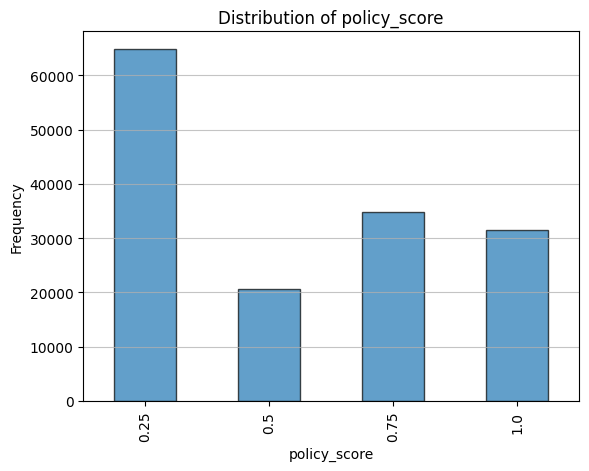

In [9]:
iea_scored_policies['policy_score'].value_counts().sort_index().plot(kind='bar', edgecolor='black', alpha=0.7)
plt.title('Distribution of policy_score')
plt.xlabel('policy_score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [10]:
# How many policies each country has?
policies_per_country_df = iea_scored_policies['iso_alpha_3'].value_counts().reset_index()
policies_per_country_df.columns = ['iso_alpha_3', 'policy_count']
policies_per_country_df.head()

,iso_alpha_3,policy_count
0,USA,10816
1,CAN,5062
2,AUS,4819
3,DEU,4352
4,EUR,4068


In [11]:
policies_per_country_df.tail(120)

,iso_alpha_3,policy_count
96,SLV,332
97,ZMB,330
98,BGR,329
99,SEN,318
100,LSO,296
...,...,...
211,ESH,10
212,MCO,9
213,SMR,8
214,PLW,8


In [12]:
oecd_countries_iso3 = [
    "AUS",  # Australia
    "AUT",  # Austria
    "BEL",  # Belgium
    "CAN",  # Canada
    "CHL",  # Chile
    "COL",  # Colombia
    "CZE",  # Czech Republic
    "DNK",  # Denmark
    "EST",  # Estonia
    "FIN",  # Finland
    "FRA",  # France
    "DEU",  # Germany
    "GRC",  # Greece
    "HUN",  # Hungary
    "ISL",  # Iceland
    "IRL",  # Ireland
    "ISR",  # Israel
    "ITA",  # Italy
    "JPN",  # Japan
    "KOR",  # South Korea
    "LVA",  # Latvia
    "LTU",  # Lithuania
    "LUX",  # Luxembourg
    "MEX",  # Mexico
    "NLD",  # Netherlands
    "NZL",  # New Zealand
    "NOR",  # Norway
    "POL",  # Poland
    "PRT",  # Portugal
    "SVK",  # Slovakia
    "SVN",  # Slovenia
    "ESP",  # Spain
    "SWE",  # Sweden
    "CHE",  # Switzerland
    "TUR",  # Turkey
    "GBR",  # United Kingdom
    "USA"   # United States
]

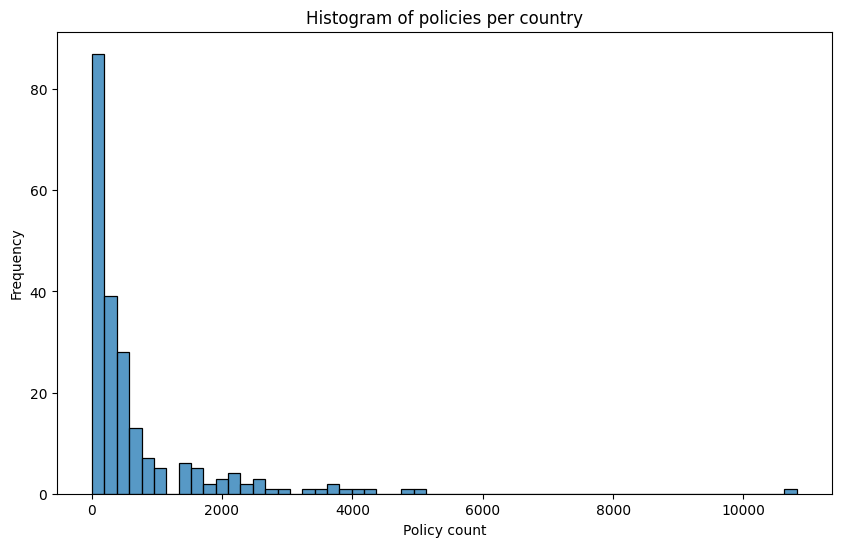

In [13]:
def plot_histogram_of_policies(policies_df):
    """
    Plots a histogram of policy counts per country.

    Parameters:
    policies_df (pd.DataFrame): DataFrame containing 'policy_count' column.

    Returns:
    None
    """
    plt.figure(figsize=(10, 6))
    sns.histplot(policies_df['policy_count'])
    plt.title('Histogram of policies per country')
    plt.xlabel('Policy count')
    plt.ylabel('Frequency')
    plt.show()

plot_histogram_of_policies(policies_per_country_df)


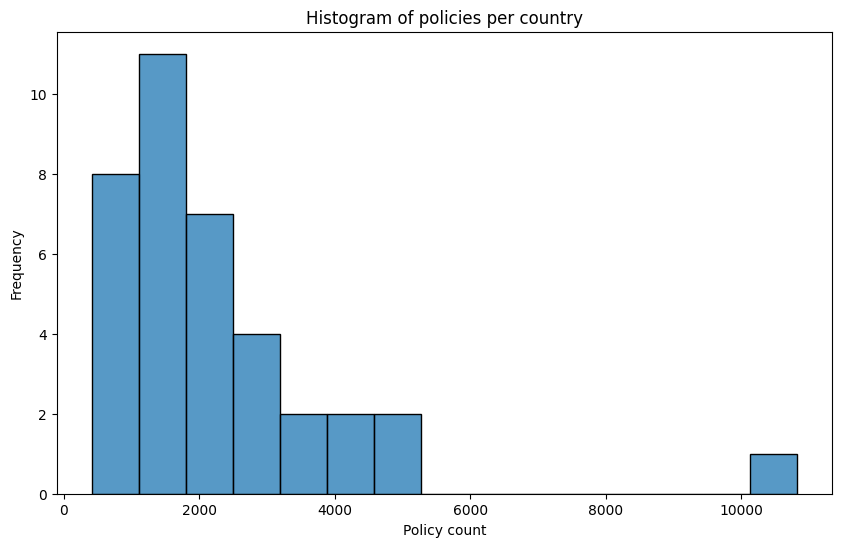

In [14]:
plot_histogram_of_policies(policies_per_country_df[policies_per_country_df.iso_alpha_3.isin(oecd_countries_iso3)])

In [15]:
iea_scored_cpsi = iea_scored_policies.groupby(['iso_alpha_3', 'year']).agg(
    avg_policy_score=('policy_score', 'mean'),
    policy_count=('policy_score', 'count'),
    dominant_topic=('topic_theme_14_refined', lambda x: x.mode()[0] if not x.isna().all() else np.nan),
    dominant_category=('category_theme_27', lambda x: x.mode()[0] if not x.isna().all() else np.nan)
).reset_index()

# add log policy count term
iea_scored_cpsi['log_policy_count'] = np.log1p(iea_scored_cpsi['policy_count'])

# Composite index: average score *  log of policy count
iea_scored_cpsi['CPSI'] = iea_scored_cpsi['avg_policy_score'] *  iea_scored_cpsi['log_policy_count']


iea_scored_cpsi.head()


,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI
0,AFG,1971,0.75,1,Energy,Solar Power,0.693147,0.51986
1,AFG,1972,0.75,1,Energy,Solar Power,0.693147,0.51986
2,AFG,1973,0.75,1,Energy,Solar Power,0.693147,0.51986
3,AFG,1974,0.75,1,Energy,Solar Power,0.693147,0.51986
4,AFG,1975,0.75,1,Energy,Solar Power,0.693147,0.51986


In [16]:
iea_scored_cpsi[iea_scored_cpsi['iso_alpha_3'] == 'CHE'].tail()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI
1417,CHE,2024,0.636842,95,Cross-cutting / Economy-wide,Other,4.564348,2.906769
1418,CHE,2025,0.636842,95,Cross-cutting / Economy-wide,Other,4.564348,2.906769
1419,CHE,2026,0.636842,95,Cross-cutting / Economy-wide,Other,4.564348,2.906769
1420,CHE,2027,0.636842,95,Cross-cutting / Economy-wide,Other,4.564348,2.906769
1421,CHE,2028,0.636842,95,Cross-cutting / Economy-wide,Other,4.564348,2.906769


In [17]:
iea_scored_cpsi[iea_scored_cpsi['iso_alpha_3'] == 'USA'].tail()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI
8772,USA,2024,0.483670,643,Cross-cutting / Economy-wide,Other,6.467699,3.128234
8773,USA,2025,0.483670,643,Cross-cutting / Economy-wide,Other,6.467699,3.128234
8774,USA,2026,0.483670,643,Cross-cutting / Economy-wide,Other,6.467699,3.128234
8775,USA,2027,0.483721,645,Cross-cutting / Economy-wide,Other,6.470800,3.130061
8776,USA,2028,0.483721,645,Cross-cutting / Economy-wide,Other,6.470800,3.130061


In [18]:
iea_scored_cpsi[iea_scored_cpsi['iso_alpha_3'] == 'BMU']

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI
954,BMU,2014,1.0,1,Energy,Solar Power,0.693147,0.693147
955,BMU,2015,1.0,1,Energy,Solar Power,0.693147,0.693147
956,BMU,2016,1.0,1,Energy,Solar Power,0.693147,0.693147
957,BMU,2017,1.0,1,Energy,Solar Power,0.693147,0.693147
958,BMU,2018,1.0,1,Energy,Solar Power,0.693147,0.693147
959,BMU,2019,1.0,1,Energy,Solar Power,0.693147,0.693147
960,BMU,2020,1.0,1,Energy,Solar Power,0.693147,0.693147
961,BMU,2021,1.0,1,Energy,Solar Power,0.693147,0.693147
962,BMU,2022,1.0,1,Energy,Solar Power,0.693147,0.693147
963,BMU,2023,1.0,1,Energy,Solar Power,0.693147,0.693147


In [19]:
# Create a df with the avg avg_policy_score and avg_policy_count for each country
iea_scored_cpsi_avg = iea_scored_cpsi.groupby('iso_alpha_3').agg(
    avg_policy_score=('avg_policy_score', 'mean'),
    avg_policy_count=('policy_count', 'mean'),
    avg_CPSI=('CPSI', 'mean')
).reset_index()
iea_scored_cpsi_avg = iea_scored_cpsi_avg.sort_values(by='avg_policy_score', ascending=False)
iea_scored_cpsi_avg.head(20)

,iso_alpha_3,avg_policy_score,avg_policy_count,avg_CPSI
4,ANT,1.000000,1.000000,0.693147
8,ATF,1.000000,1.000000,0.693147
46,CYM,1.000000,1.000000,0.693147
24,BMU,1.000000,1.000000,0.693147
65,FLK,1.000000,1.000000,0.693147
81,GUF,1.000000,1.000000,0.693147
210,WLF,1.000000,1.000000,0.693147
90,IOT,1.000000,1.000000,0.693147
153,PCN,1.000000,1.000000,0.693147
163,PYF,1.000000,1.000000,0.693147


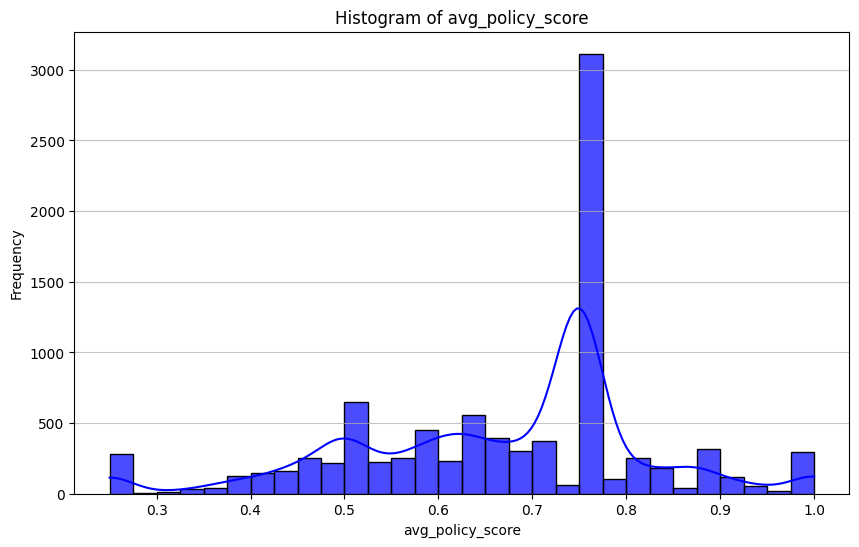

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(iea_scored_cpsi['avg_policy_score'], bins=30, kde=True, color='blue', alpha=0.7)
plt.title('Histogram of avg_policy_score')
plt.xlabel('avg_policy_score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Tunning the index

In [21]:
def plot_cpsi_and_policy_trend(df, countries, cpsi_col='CPSI', policy_count_col='policy_count', year_col='year', show_policy_count=False, quartiles=False):
    """
    Plots CPSI and policy count trends for selected countries.

    Parameters:
    df (pd.DataFrame): DataFrame containing CPSI and policy count data.
    countries (list): List of country ISO alpha-3 codes to include in the plot.
    cpsi_col (str): Column name for CPSI values.
    policy_count_col (str): Column name for policy count values.
    year_col (str): Column name for year values.
    show_policy_count (bool): Whether to include the secondary axis for policy count.

    Returns:
    None
    """
    # Filter data for the selected countries
    filtered_data = df[df['iso_alpha_3'].isin(countries)]

    # Plotting
    plt.figure(figsize=(14, 8))

    # Set up main axis
    ax1 = plt.gca()

    # Plot CPSI trend
    for country in countries:
        country_data = filtered_data[filtered_data['iso_alpha_3'] == country].sort_values(year_col)
        cpsi_smoothed = country_data.set_index(year_col)[cpsi_col].rolling(window=2, min_periods=1).mean()
        ax1.plot(cpsi_smoothed.index, cpsi_smoothed.values, label=f'{country} (CPSI)', linewidth=2.5)

    if quartiles:

        # Calculate quartiles
        q1 = filtered_data[cpsi_col].quantile(0.25)
        q2 = filtered_data[cpsi_col].quantile(0.50)  # Median
        q3 = filtered_data[cpsi_col].quantile(0.75)

        # Plot quartile lines
        ax1.axhline(q1, color='red', linestyle='--', linewidth=1.5, label=f'Q1: {q1:.2f}')
        ax1.axhline(q2, color='red', linestyle='--', linewidth=1.5, label=f'Q2 (Median): {q2:.2f}')
        ax1.axhline(q3, color='red', linestyle='--', linewidth=1.5, label=f'Q3: {q3:.2f}')

    ax1.set_ylabel(cpsi_col, fontsize=12)
    ax1.set_xlabel('Year')
    ax1.set_title(f'{cpsi_col} vs Policy Count Over Time – Selected Countries', fontsize=16)
    ax1.grid(alpha=0.3)

    if show_policy_count:
        # Secondary Y-axis for policy count
        ax2 = ax1.twinx()
        for country in countries:
            country_data = filtered_data[filtered_data['iso_alpha_3'] == country].sort_values(year_col)
            ax2.plot(country_data[year_col], country_data[policy_count_col], linestyle='--', alpha=0.5, label=f'{country} (Policies)')

        ax2.set_ylabel('Number of Policies', fontsize=12)
        ax2.set_ylim(0, filtered_data[policy_count_col].max() + 5)

        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    else:
        # Legend for CPSI only
        ax1.legend(loc='upper left', fontsize=9)

    plt.tight_layout()
    plt.show()

In [22]:
# ------------------------------------------------------------------
# 1. Log-scaling, up-weighted by a constant α
# ------------------------------------------------------------------
def cpsi_log_alpha(df, *, alpha=2.0,
                   score_col='avg_policy_score',
                   count_col='policy_count'):
    """
    CPSI = avg_score × α × ln(1 + n)
    """
    log_term = alpha * np.log1p(df[count_col])
    return df[score_col] * log_term


# ------------------------------------------------------------------
# 2. Box–Cox-style power transform with exponent θ (0<θ<1)
# ------------------------------------------------------------------
def cpsi_power(df, *, theta=0.4,
               score_col='avg_policy_score',
               count_col='policy_count'):
    """
    CPSI = avg_score × [(1+n)^θ – 1] / θ
    θ→0 reproduces the log; θ→1 approaches linear.
    """
    n_pow = ((1 + df[count_col]) ** theta - 1) / theta
    return df[score_col] * n_pow


# ------------------------------------------------------------------
# 3. Weighted sum after min–max scaling (explicit trade-off)
# ------------------------------------------------------------------
def cpsi_weighted(df, *, w_score=0.6, w_count=0.4,
                  score_col='avg_policy_score',
                  count_col='policy_count'):
    """
    CPSI = w_s × scaled(avg_score) + w_c × scaled(count)
    Both components are on [0,1] after min–max scaling.
    """
    mm = MinMaxScaler()
    score_scaled = mm.fit_transform(df[[score_col]]).squeeze()
    count_scaled = mm.fit_transform(df[[count_col]]).squeeze()
    return w_score * score_scaled + w_count * count_scaled


# ------------------------------------------------------------------
# 4. Geometric mean with tunable elasticities α, β
# ------------------------------------------------------------------
def cpsi_geom(df, *, alpha=0.5, beta=0.5,
              score_col='avg_policy_score',
              count_col='policy_count'):
    """
    CPSI = (avg_score)^β × (1 + n)^α
    """
    return (df[score_col] ** beta) * ((1 + df[count_col]) ** alpha)


# ------------------------------------------------------------------
# 5. Piece-wise (linear → √) scaling to curb runaway counts
# ------------------------------------------------------------------
def cpsi_piecewise(df, *, cutoff=20,
                   score_col='avg_policy_score',
                   count_col='policy_count'):
    """
    If n ≤ cutoff:          count_adj = n
    If n  > cutoff:         count_adj = cutoff + √(n − cutoff)
    CPSI = avg_score × count_adj
    """
    n = df[count_col].values
    count_adj = np.where(n <= cutoff, n, cutoff + np.sqrt(n - cutoff))
    return df[score_col] * count_adj


# ---------------------------------------------------------------
# ---- Example usage -------------------------------------------
# ---------------------------------------------------------------
# Add a CPSI column for each variant so you can compare them side-by-side
# iea_scored_cpsi['CPSI_log_alpha']  = cpsi_log_alpha(iea_scored_cpsi, alpha=3.0)
# iea_scored_cpsi['CPSI_power']      = cpsi_power(iea_scored_cpsi, theta=0.4)
# iea_scored_cpsi['CPSI_power_2']   = cpsi_power(iea_scored_cpsi, theta=0.2)
iea_scored_cpsi['CPSI_power_3']   = cpsi_power(iea_scored_cpsi, theta=0.6)
# iea_scored_cpsi['CPSI_weighted']   = cpsi_weighted(iea_scored_cpsi, w_score=0.6, w_count=0.4) 
# iea_scored_cpsi['CPSI_geom']       = cpsi_geom(iea_scored_cpsi, alpha=0.6, beta=0.4)
# iea_scored_cpsi['CPSI_geom_2']     = cpsi_geom(iea_scored_cpsi, alpha=0.4, beta=0.6)
# iea_scored_cpsi['CPSI_geom_3']     = cpsi_geom(iea_scored_cpsi, alpha=0.5, beta=0.5)
iea_scored_cpsi['CPSI_geom_4']     = cpsi_geom(iea_scored_cpsi, alpha=0.7, beta=0.3)
# iea_scored_cpsi['CPSI_geom_5']     = cpsi_geom(iea_scored_cpsi, alpha=0.3, beta=0.7)
# iea_scored_cpsi['CPSI_geom_6']     = cpsi_geom(iea_scored_cpsi, alpha=0.1, beta=0.9)
iea_scored_cpsi['CPSI_geom_7']     = cpsi_geom(iea_scored_cpsi, alpha=0.8, beta=0.2)
# iea_scored_cpsi['CPSI_piecewise']  = cpsi_piecewise(iea_scored_cpsi, cutoff=20)

In [23]:
iea_scored_cpsi.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7
0,AFG,1971,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
1,AFG,1972,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
2,AFG,1973,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
3,AFG,1974,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
4,AFG,1975,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752


In [24]:
# -------------------------------------------------------------------
# Helper: get the CPSI columns automatically if the user doesn’t pass any
# -------------------------------------------------------------------
def _default_index_cols(df, index_cols):
    if index_cols is not None:
        return index_cols
    # pick every column whose name starts with “CPSI”
    return [c for c in df.columns if c.upper().startswith("CPSI")]

# -------------------------------------------------------------------
# 1. Histogram grid
# -------------------------------------------------------------------
def plot_cpsi_histograms(df, index_cols=None, bins=30, figsize=(12, 2.5)):
    """
    One histogram per CPSI variant (small-multiples layout).
    """
    cols = _default_index_cols(df, index_cols)
    n     = len(cols)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(figsize[0], figsize[1]*n), sharex=False)

    if n == 1:       # keep indexing simple for the single-plot case
        axes = [axes]

    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=bins, alpha=0.7)
        ax.set_title(f'Histogram: {col}')
        ax.set_ylabel('Freq.')

    axes[-1].set_xlabel('CPSI value')
    fig.tight_layout()
    plt.show()


# -------------------------------------------------------------------
# 2. KDE overlay
# -------------------------------------------------------------------
def plot_cpsi_kde(df, index_cols=None, figsize=(10, 6)):
    """
    Overlays kernel-density curves for all CPSI variants in a single plot.
    """
    cols = _default_index_cols(df, index_cols)
    plt.figure(figsize=figsize)

    for col in cols:
        sns.kdeplot(df[col].dropna(), label=col, linewidth=1.7)

    plt.title('CPSI variants – KDE overlay')
    plt.legend()
    plt.xlabel('CPSI value')
    plt.ylabel('Density')
    plt.ylim(0, 5)
    plt.xlim(0, 5)
    plt.show()


# -------------------------------------------------------------------
# 3. Side-by-side box-plot
# -------------------------------------------------------------------
def plot_cpsi_boxplot(df, index_cols=None, figsize=(10, 5)):
    """
    Shows spread & outliers side-by-side across CPSI variants.
    """
    cols = _default_index_cols(df, index_cols)
    plt.figure(figsize=figsize)
    sns.boxplot(data=df[cols], orient='h', showfliers=True)
    plt.title('CPSI variants – box-plot comparison')
    plt.xlabel('CPSI value')
    plt.yticks(rotation=0)
    plt.show()


# -------------------------------------------------------------------
# 4. Convenience wrapper: run all three
# -------------------------------------------------------------------
def compare_cpsi_distributions(df, index_cols=None, bins=30):
    """
    Quick exploratory combo: histograms, KDE overlay, and box-plot.
    """
    plot_cpsi_histograms(df, index_cols=index_cols, bins=bins)
    plot_cpsi_kde(df, index_cols=index_cols)
    plot_cpsi_boxplot(df, index_cols=index_cols)


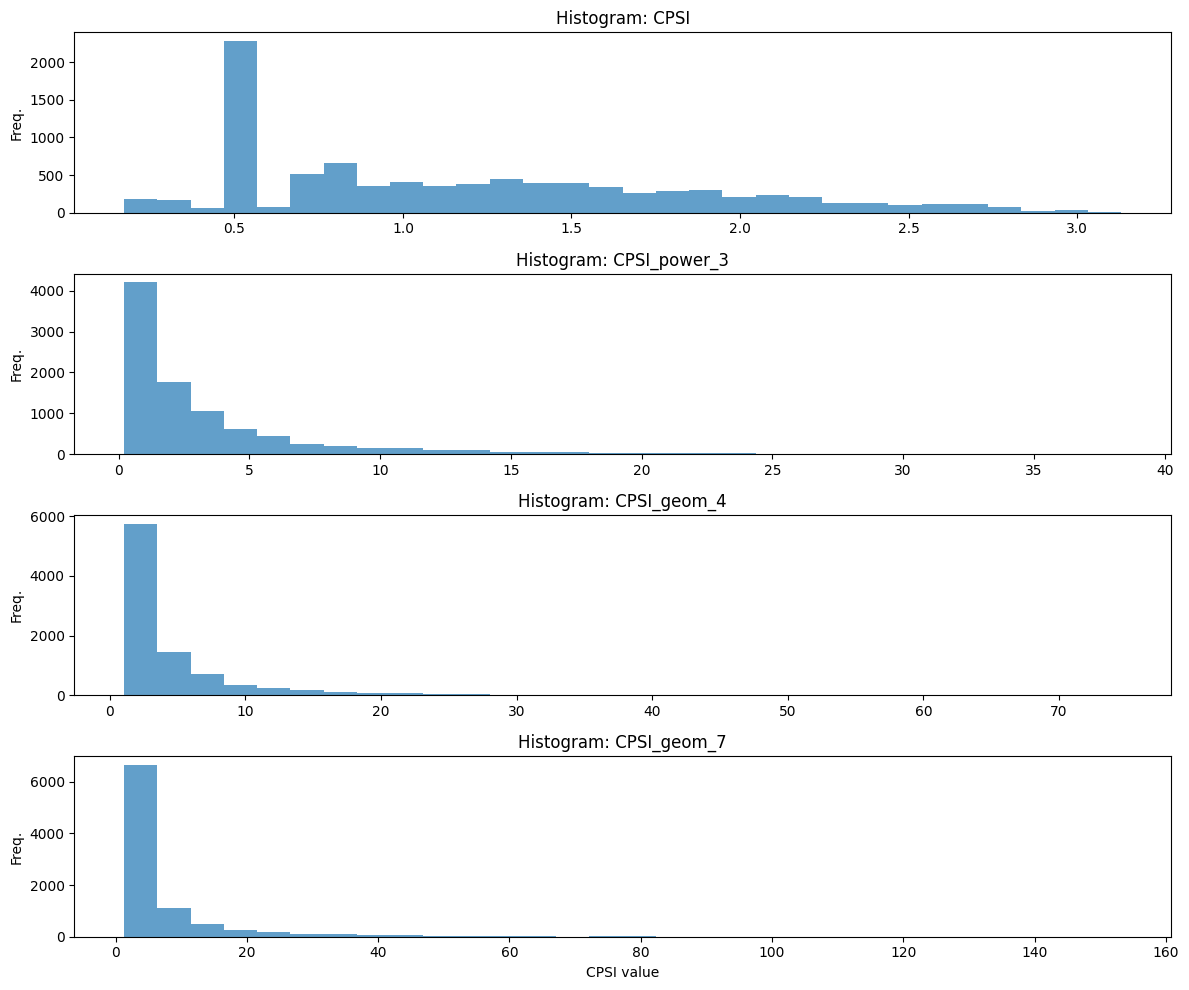

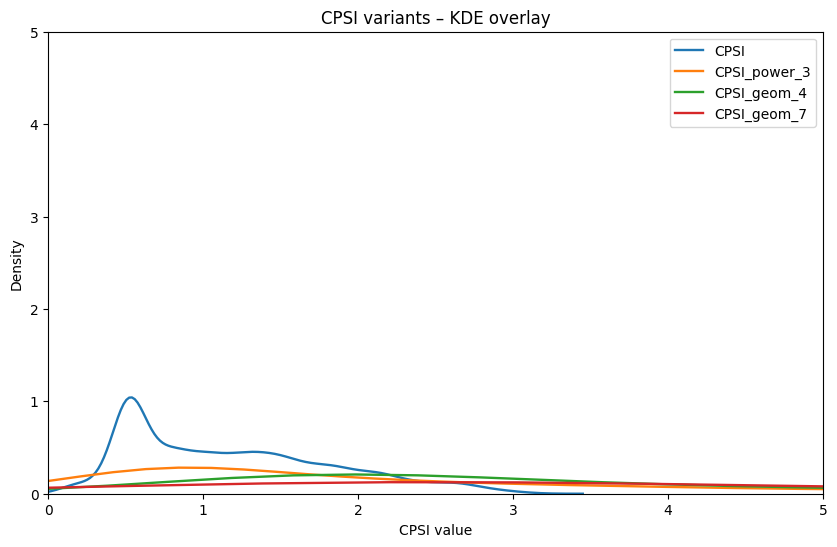

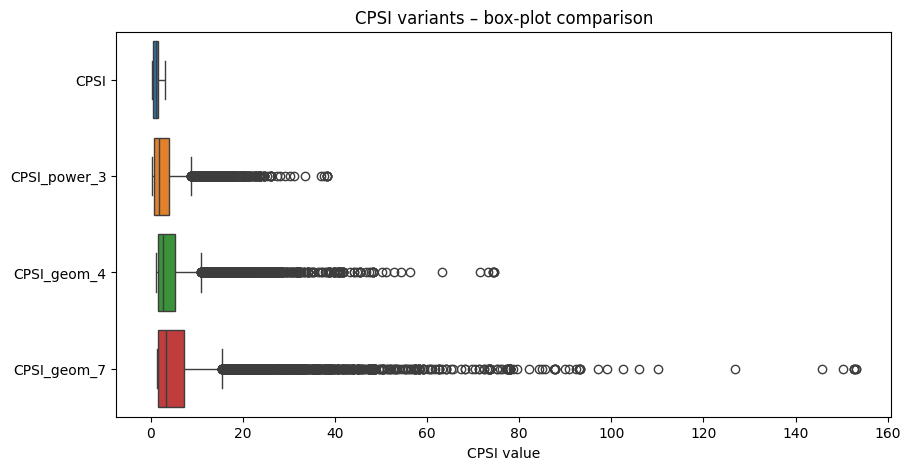

In [25]:
# After you’ve added the five CPSI variants to iea_scored_cpsi:
compare_cpsi_distributions(iea_scored_cpsi)

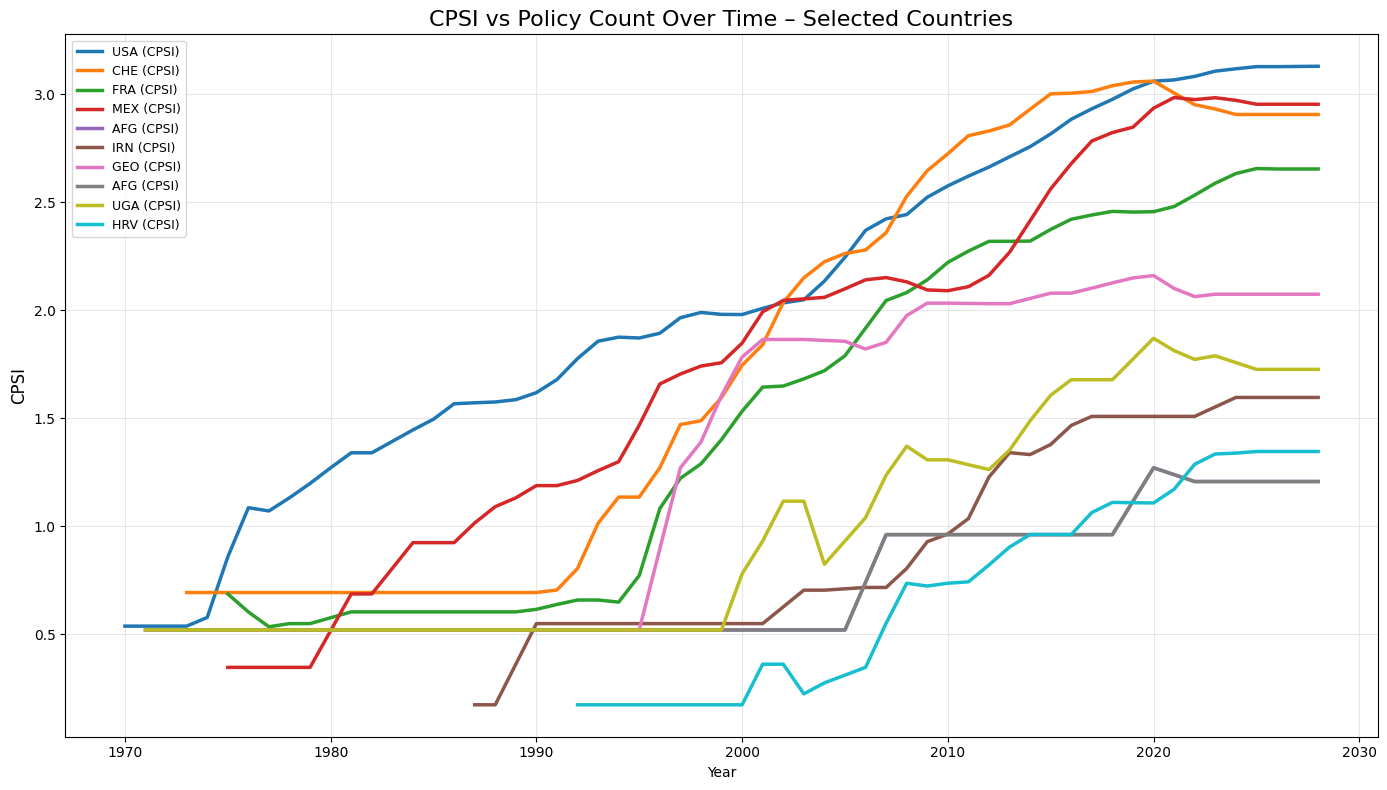

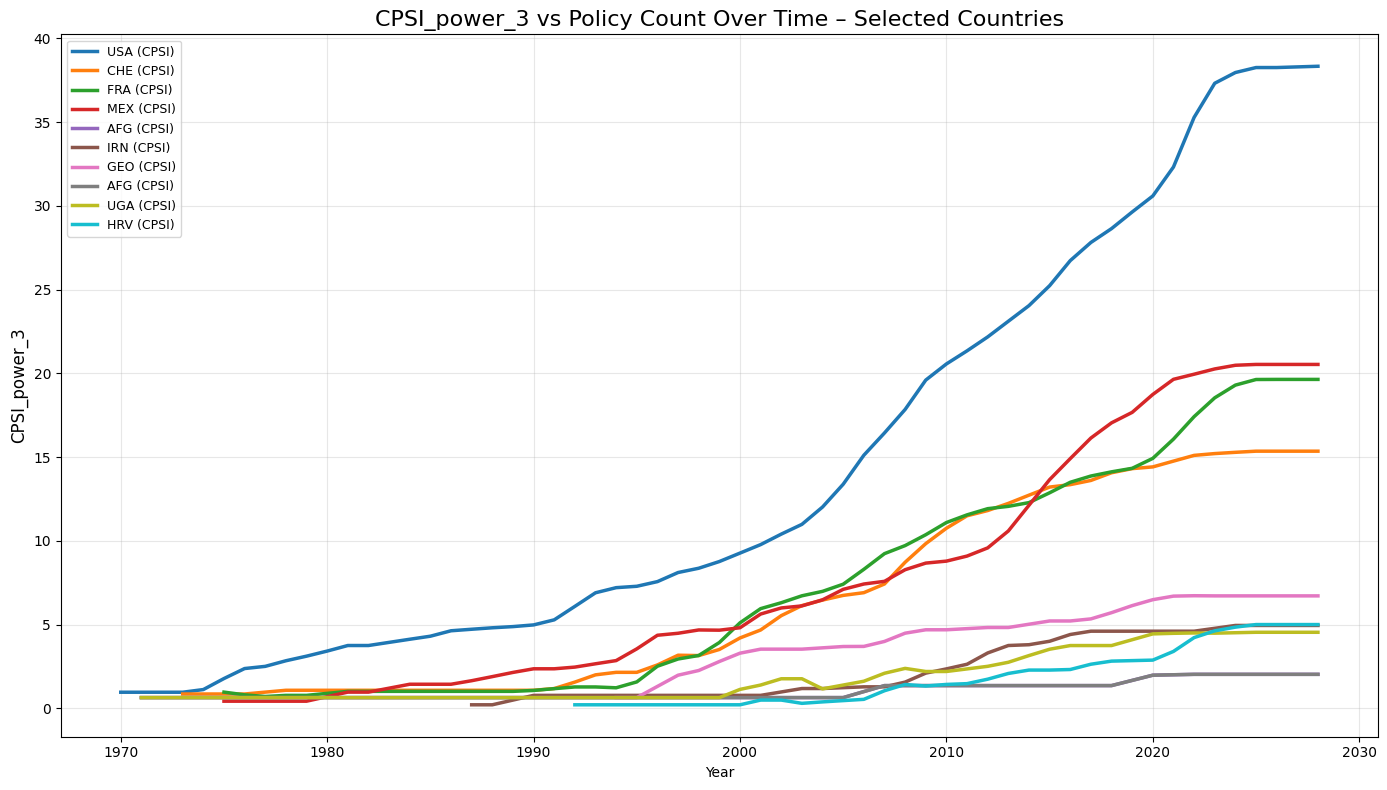

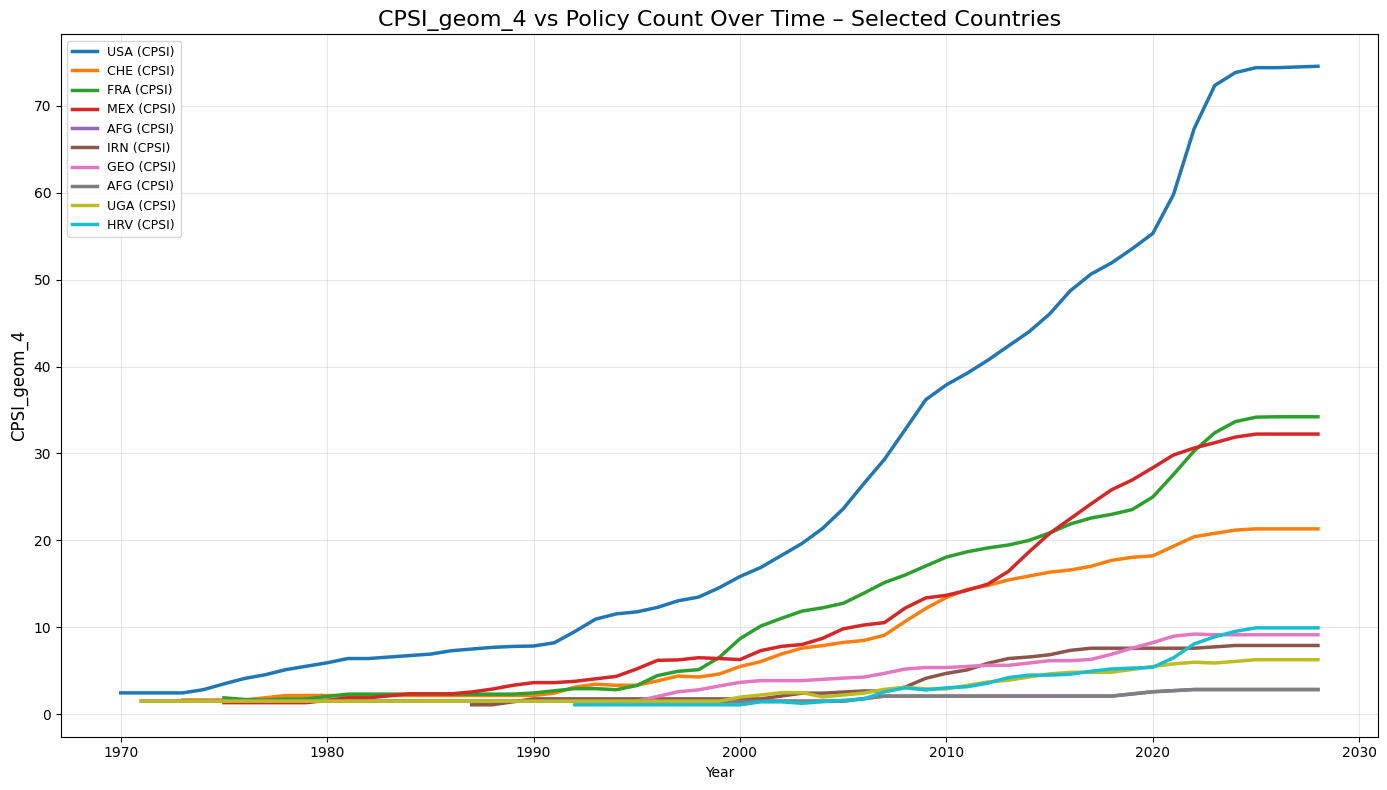

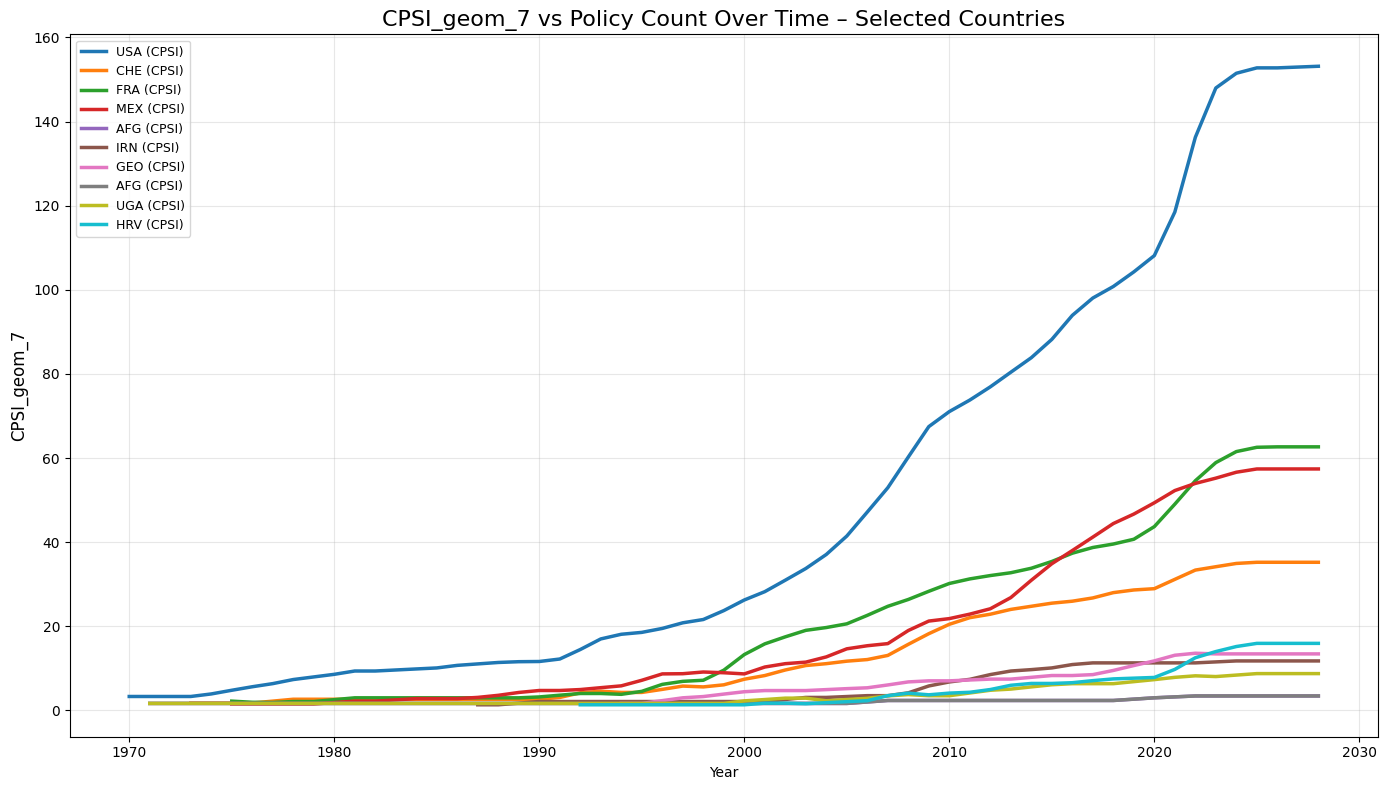

In [26]:
countries_to_analyze = ['USA', 'CHE', 'FRA', 'MEX', 'AFG', 'IRN', 'GEO', 'AFG', 'UGA', 'HRV']
index_col_names = [col for col in iea_scored_cpsi.columns if col.startswith('CPSI')]
for col in index_col_names:
    try:
        plot_cpsi_and_policy_trend(iea_scored_cpsi, countries_to_analyze, cpsi_col=col, policy_count_col='policy_count', year_col='year')
    except Exception as e:
        print(f"Error plotting {col} for countries {countries_to_analyze}: {e}")
        continue

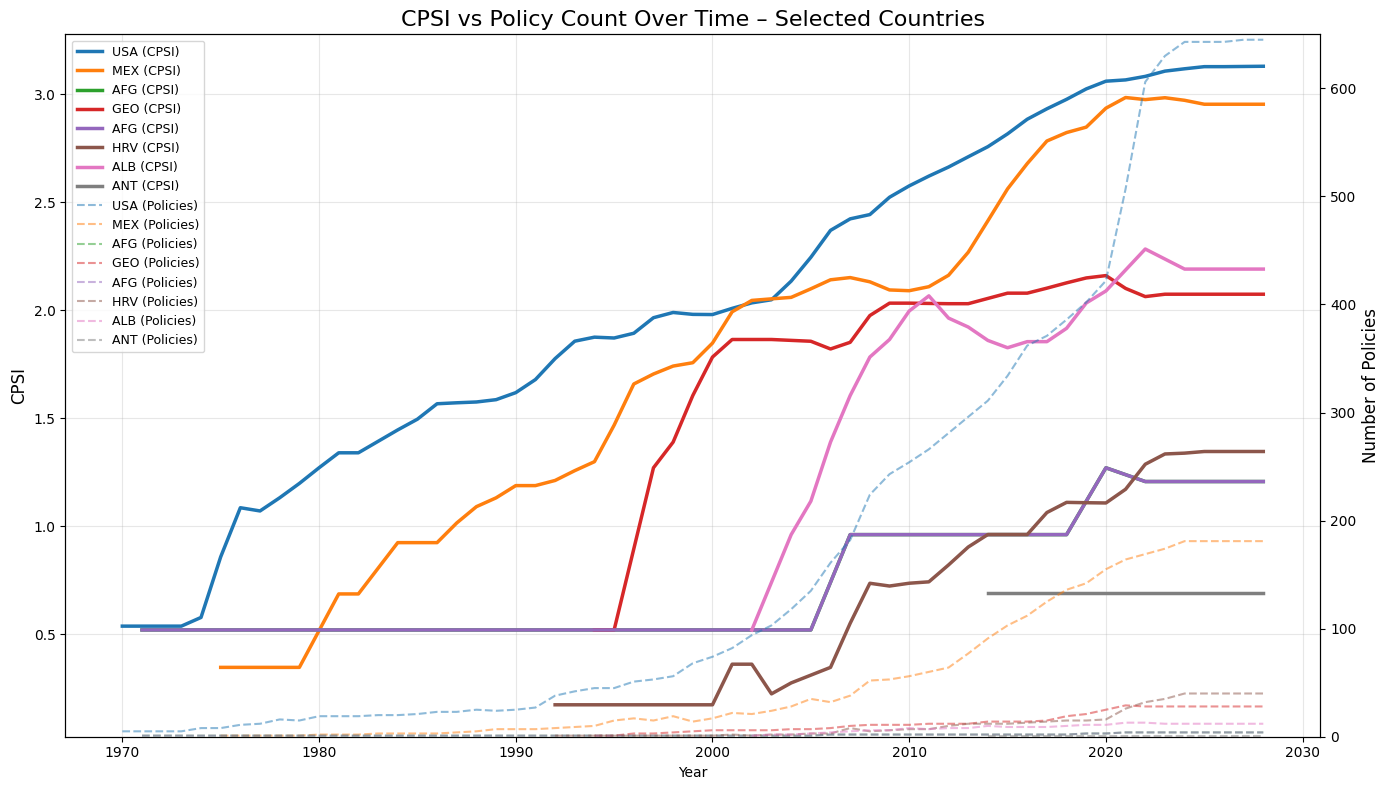

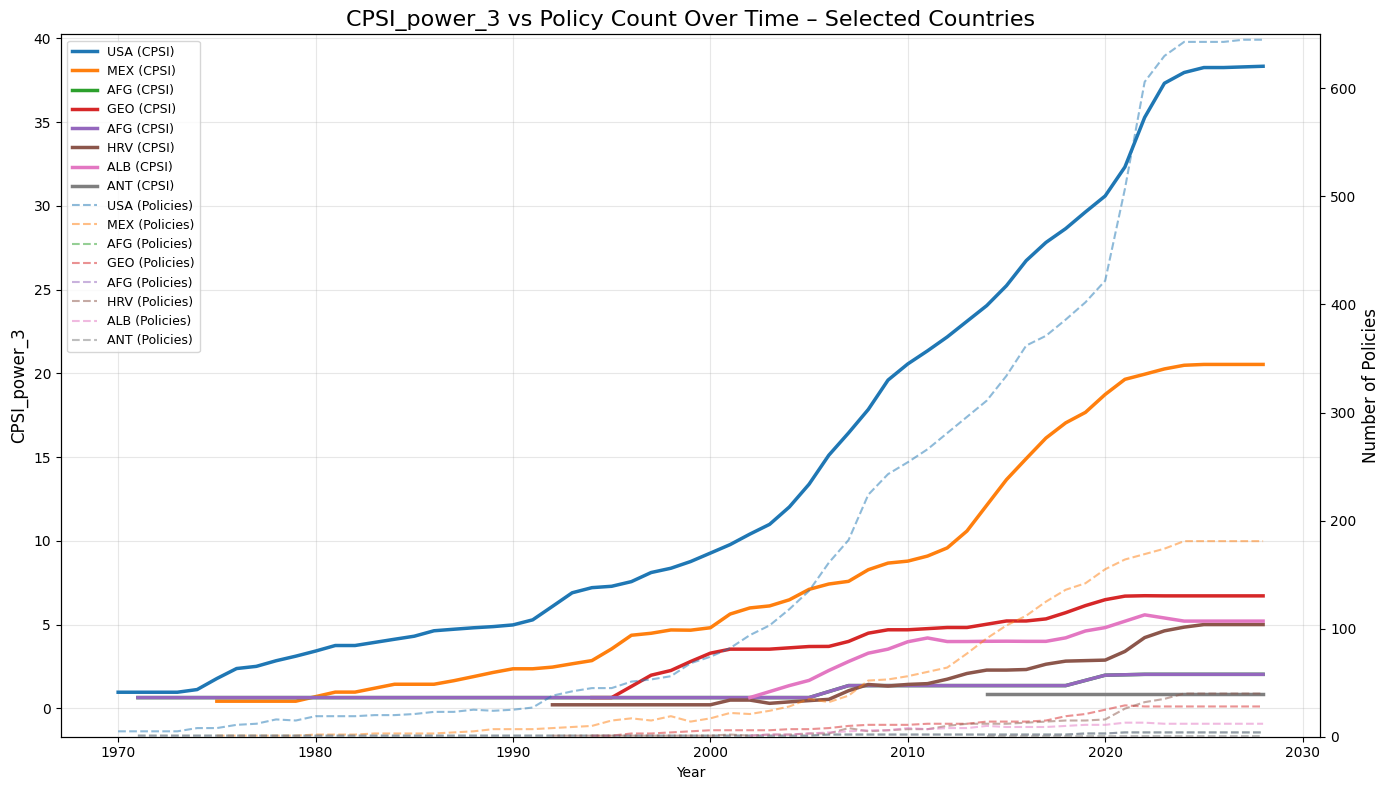

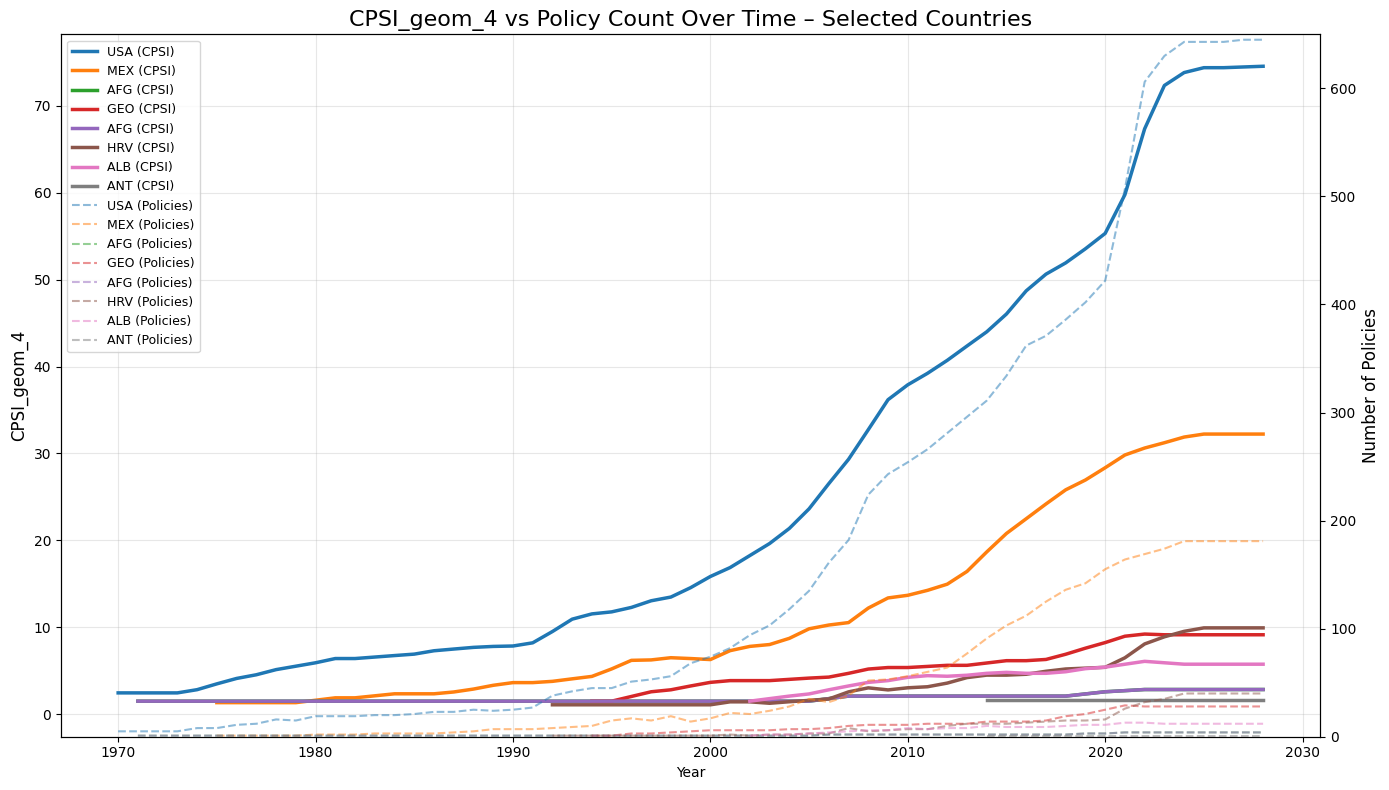

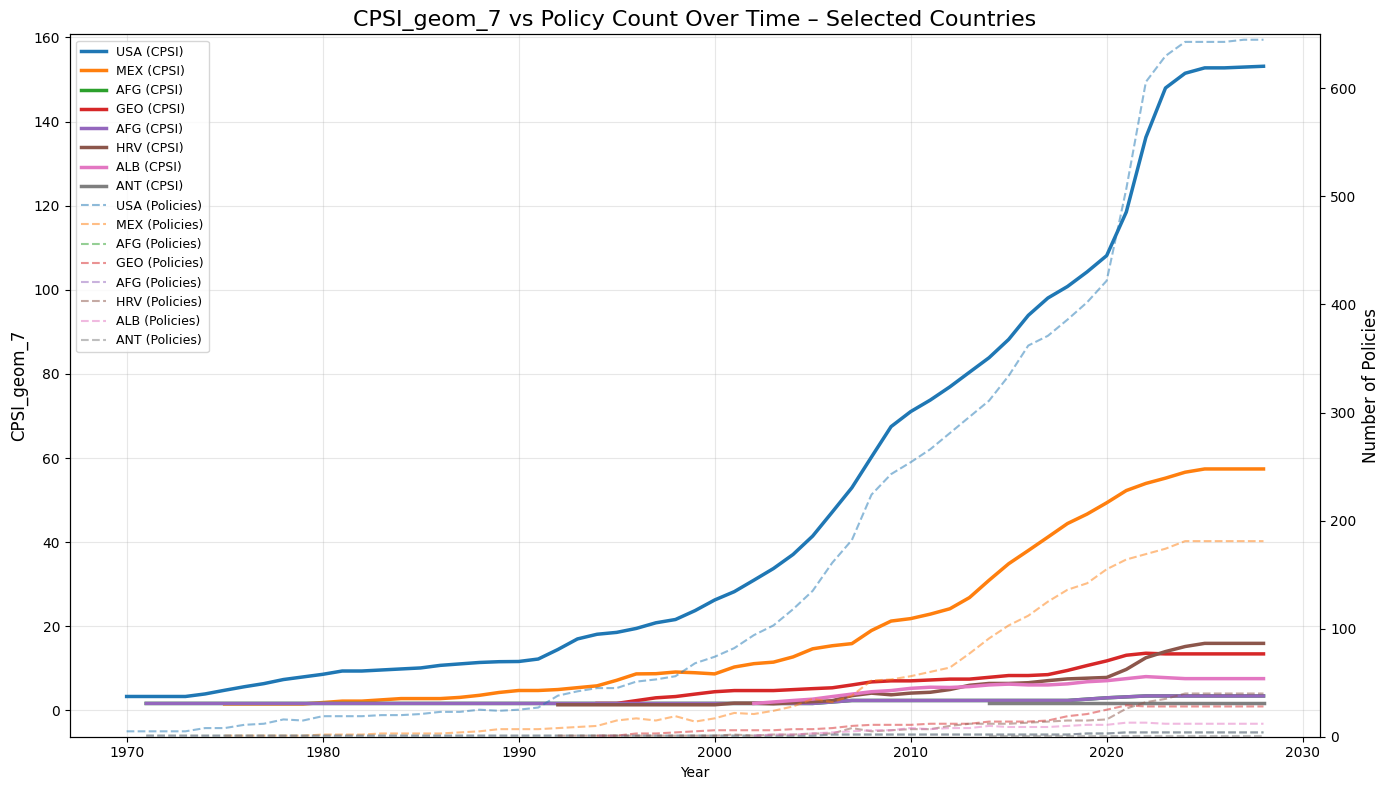

In [27]:
countries_to_analyze = ['USA', 'MEX', 'AFG', 'GEO', 'AFG', 'HRV', 'ALB', 'ANT']
index_col_names = [col for col in iea_scored_cpsi.columns if col.startswith('CPSI')]
for col in index_col_names:
    try:
        plot_cpsi_and_policy_trend(iea_scored_cpsi, countries_to_analyze, cpsi_col=col, policy_count_col='policy_count', year_col='year', show_policy_count=True)
    except Exception as e:
        print(f"Error plotting {col} for countries {countries_to_analyze}: {e}")
        continue

In [28]:
# Save final datasets
iea_scored_policies.to_csv(os.path.join(PROCESSED_DATA_DIR_PATH, 'IEA_scored_policies.csv'), index=False)
iea_scored_cpsi.to_csv(os.path.join(PROCESSED_DATA_DIR_PATH, 'IEA_scored_cpsi.csv'), index=False)